# Feature Extraction & Distribution Comparison

한국/미국 손해배상 판례 corpus의 legal feature distribution 비교

**파이프라인**
1. 설치 및 설정
2. 데이터 로드 (`preprocessed_cases.csv`)
3. Feature extraction
   - 3-1. Surface/Structural features
   - 3-2. Regex-based features (statute, precedent citation)
   - 3-3. Dictionary-based features (doctrine, remedy, procedure, jurisdiction)
   - 3-4. Density 계산 (per 1,000 tokens)
   - 3-5. Reasoning structure features (conclusion_position, party_argument_density)
4. Feature vector 저장
5. 기술통계
6. 통계 검정 (Mann-Whitney U + effect size)
7. 시각화 (bar plot, box plot, heatmap, PCA)

## 1. 설치 및 설정

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ── 한글 폰트 설정 ───────────────────────────────────────
# 시스템에 설치된 한글 폰트를 자동 탐색
_kr_font_candidates = [
    "Malgun Gothic", "Apple SD Gothic Neo", "NanumGothic",
    "NanumBarunGothic", "Noto Sans KR", "DejaVu Sans",
]
_available = {f.name for f in fm.fontManager.ttflist}
_kr_font = next((f for f in _kr_font_candidates if f in _available), None)
if _kr_font:
    matplotlib.rc("font", family=_kr_font)
matplotlib.rc("axes", unicode_minus=False)

# ── 경로 ────────────────────────────────────────────────
DATA_DIR   = Path("./outputs")
PREPROCESSED_CSV = DATA_DIR / "preprocessed_cases.csv"
FV_OUTPUT  = DATA_DIR / "feature_vectors.csv"   # 판례별 feature vector
PLOT_DIR   = DATA_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("설정 완료")
print(f"  입력      : {PREPROCESSED_CSV}")
print(f"  출력      : {FV_OUTPUT}")

설정 완료
  입력      : outputs\preprocessed_cases.csv
  출력      : outputs\feature_vectors.csv


## 2. 데이터 로드

In [2]:
all_cases_df = pd.read_csv(PREPROCESSED_CSV, encoding="utf-8-sig")

kr_df = all_cases_df[all_cases_df["jurisdiction"].eq("KR")].copy()
us_df = all_cases_df[all_cases_df["jurisdiction"].eq("US")].copy()

# reasoning_text -> clean_text -> raw_text 순서로 feature 추출용 텍스트 선택
for df in [kr_df, us_df]:
    df["_text"] = ""
    for col in ["raw_text", "clean_text", "reasoning_text"]:
        if col in df.columns:
            df["_text"] = df[col].fillna("").replace("", np.nan).fillna(df["_text"])
    df["_text"] = df["_text"].fillna("")

us_before_count = len(us_df)
us_df = us_df[us_df["_text"].str.strip().ne("")].copy()
excluded_us_count = us_before_count - len(us_df)

print(f"KR: {len(kr_df)}건  |  컬럼: {list(kr_df.columns)}")
print(f"US: {len(us_df)}건  |  컬럼: {list(us_df.columns)}")
print(f"비교에서 제외된 US 빈 텍스트 행: {excluded_us_count}건")

KR: 50건  |  컬럼: ['case_id', 'jurisdiction', 'country', 'court_name', 'court_level', 'decision_date', 'case_name', 'case_number_or_citation', 'source', 'case_type_keyword', 'raw_text', 'clean_text', 'reasoning_text', 'raw_char_count', 'clean_char_count', 'reasoning_char_count', 'clean_token_count', 'clean_sentence_count', 'token_count', 'sentence_count', 'avg_sentence_length', 'has_reasoning_or_opinion_marker', 'meets_min_reasoning_tokens', 'preprocess_notes', '_text']
US: 47건  |  컬럼: ['case_id', 'jurisdiction', 'country', 'court_name', 'court_level', 'decision_date', 'case_name', 'case_number_or_citation', 'source', 'case_type_keyword', 'raw_text', 'clean_text', 'reasoning_text', 'raw_char_count', 'clean_char_count', 'reasoning_char_count', 'clean_token_count', 'clean_sentence_count', 'token_count', 'sentence_count', 'avg_sentence_length', 'has_reasoning_or_opinion_marker', 'meets_min_reasoning_tokens', 'preprocess_notes', '_text']
비교에서 제외된 US 빈 텍스트 행: 3건


## 3. Feature Extraction

### 3-1. Regex 및 사전 정의

In [3]:
# ════════════════════════════════════════════════════════
#  REGEX PATTERNS
# ════════════════════════════════════════════════════════

# ── 한국 조문 인용 ───────────────────────────────────────
# 민법 제750조, 같은 법 제393조, 이 사건 법률 제3조
KR_STATUTE_RE = re.compile(
    r"(?:민법|상법|형법|민사소송법|민사집행법|국가배상법|도로교통법|근로기준법"
    r"|제조물 ?책임법|자동차손해배상 ?보장법|의료법|건축법|환경정책기본법"
    r"|같은 법|이 법|위 법|이 사건 법률)"
    r"\s*제\d+조(?:의\d+)?(?:\s*제\d+항)?(?:\s*제\d+호)?"
)

# ── 한국 판례 인용 (두 가지 형태) ───────────────────────
# 형태 A: 대법원 2015다12345 판결
# 형태 B: 대법원 2015. 3. 26. 선고 2014다12345 판결
KR_PRECEDENT_RE = re.compile(
    r"(?:대법원|헌법재판소|서울고등법원|부산고등법원|대구고등법원)"
    r"(?:\s*\d{4}\.\s*\d{1,2}\.\s*\d{1,2}\.\s*선고\s*)?"
    r"\s*\d{4}\s*(?:다|가|나|라|마|카|허|두|므|브|초|재|행|구|모|오|전합)\s*\d+"
    r"(?:\s*판결|\s*결정|\s*선고)?"
)

# ── 미국 조문 인용 ───────────────────────────────────────
# 42 U.S.C. § 1983, Cal. Civ. Code § 1714, Fla. Stat. § 768
US_STATUTE_RE = re.compile(
    r"(?:\d+\s+U\.S\.C\.\s*§+\s*\d+"
    r"|[A-Z][a-z]+\.?\s*(?:Civ|Pen|Bus|Lab|Gov|Ins|Prob|Rev|Ann|Gen|Code)\.?\s*"
    r"(?:Code)?\s*§+\s*\d+"
    r"|(?:Section|section|§)\s*\d+\s+of\s+[A-Z])"
)

# ── 미국 판례 인용 ───────────────────────────────────────
# Smith v. Jones, 123 F.3d 456  /  123 U.S. 456  /  123 F. Supp. 2d 456
US_PRECEDENT_RE = re.compile(
    r"[A-Z][A-Za-z'\-]+\s+v\.\s+[A-Z][A-Za-z'\-]+"
    r"|\d+\s+(?:U\.S\.|F\.(?:\d+d|Supp\.(?:\s*\d+d)?)|S\.\s*Ct\.|L\.\s*Ed\.)"
    r"\s+\d+"
)

# ── 결론부 탐지 ──────────────────────────────────────────
KR_CONCLUSION_RE = re.compile(
    r"따라서|이유\s*(?:있다|없다)"
    r"|청구를\s*(?:인용|기각)"
    r"|주문과\s*같이\s*판결"
    r"|원고의\s*청구는"
)
US_CONCLUSION_RE = re.compile(
    r"[Ww]e\s+(?:therefore\s+)?hold"
    r"|[Aa]ccordingly[,.]?"
    r"|[Ff]or\s+(?:the\s+)?(?:foregoing\s+)?reasons"
    r"|[Jj]udgment\s+(?:is\s+)?(?:entered|granted|denied)"
    r"|[Pp]laintiff(?:'s)? (?:claims?|motion) (?:is |are )?(?:granted|denied|dismissed)"
)

# ── 당사자 주장 탐지 ─────────────────────────────────────
KR_PARTY_ARG_RE = re.compile(
    r"원고(?:는|의|가|측)\s*(?:주장|청구|진술)"
    r"|피고(?:는|의|가|측)\s*(?:주장|항변|답변)"
    r"|(?:원고|피고)(?:는|가)\s+이\s*사건"
)
US_PARTY_ARG_RE = re.compile(
    r"[Pp]laintiff\s+(?:argues?|contends?|alleges?|claims?|asserts?)"
    r"|[Dd]efendant\s+(?:argues?|contends?|asserts?|moves?|responds?)"
    r"|[Pp]etitioner\s+(?:argues?|contends?)"
    r"|[Aa]ppellant\s+(?:argues?|contends?)"
)

# ════════════════════════════════════════════════════════
#  DICTIONARIES
# ════════════════════════════════════════════════════════

KR_DOCTRINE_TERMS = [
    "상당인과관계", "과실상계", "신의성실의 원칙", "신의칙",
    "불법행위", "고의 또는 과실", "위법성", "손해",
    "인과관계", "책임제한", "위자료", "재산상 손해",
    "정신적 손해", "지연손해금", "원상회복", "손해배상책임",
    "채무불이행", "손해배상의 범위",
]
KR_REMEDY_TERMS = [
    "손해배상", "위자료", "지연손해금", "원상회복",
    "재산적 손해", "일실수입", "일실이익", "치료비",
    "개호비", "향후치료비", "장례비",
]
KR_PROCEDURE_TERMS = [
    "원심", "항소", "상고", "파기환송", "청구기각",
    "일부인용", "전부인용", "소 제기", "항소심", "1심",
    "이 사건 소",
]
KR_JURISDICTION_TERMS = [
    "대한민국", "대법원", "고등법원", "지방법원",
    "서울중앙지방법원", "서울고등법원", "헌법재판소",
]

US_DOCTRINE_TERMS = [
    "duty of care", "breach of duty", "negligence",
    "proximate cause", "causation", "foreseeability",
    "comparative negligence", "contributory negligence",
    "strict liability", "standard of care", "reasonable person",
    "but-for causation", "substantial factor",
]
US_REMEDY_TERMS = [
    "compensatory damages", "punitive damages", "nominal damages",
    "injunction", "damages", "pain and suffering",
    "emotional distress", "lost wages", "medical expenses",
    "wrongful death",
]
US_PROCEDURE_TERMS = [
    "summary judgment", "motion to dismiss", "appeal",
    "remand", "affirmed", "reversed", "de novo",
    "motion for judgment", "directed verdict",
    "judgment as a matter of law",
]
US_JURISDICTION_TERMS = [
    "United States", "federal court", "district court",
    "circuit court", "Supreme Court", "Court of Appeals",
    "state court",
]

print("Regex 패턴 및 사전 정의 완료")

Regex 패턴 및 사전 정의 완료


### 3-2. Feature 추출 함수

In [4]:
def count_regex(text: str, pattern: re.Pattern) -> int:
    """정규식 매칭 수 반환."""
    if not text:
        return 0
    return len(pattern.findall(text))


def count_dict_terms(text: str, terms: list) -> int:
    """사전 용어 등장 횟수 합산 (대소문자 무시)."""
    if not text:
        return 0
    text_lower = text.lower()
    return sum(text_lower.count(t.lower()) for t in terms)


def density_per_1000(count: int, token_count: int) -> float:
    """1,000 토큰당 밀도 계산."""
    if token_count <= 0:
        return 0.0
    return round(count / token_count * 1000, 4)


def conclusion_position(text: str, conclusion_re: re.Pattern) -> float:
    """
    결론 표현이 처음 등장하는 위치를 0~1 사이 상대값으로 반환.
    0에 가까울수록 앞쪽, 1에 가까울수록 뒤쪽.
    탐지 실패 시 -1.
    """
    if not text:
        return -1.0
    match = conclusion_re.search(text)
    if not match:
        return -1.0
    return round(match.start() / max(len(text), 1), 4)


def party_arg_density(text: str, party_re: re.Pattern, token_count: int) -> float:
    """당사자 주장 표현 밀도 (per 1,000 tokens)."""
    return density_per_1000(count_regex(text, party_re), token_count)


def safe_positive_int(value, default: int = 0) -> int:
    """NaN/빈 값/문자열 숫자를 안전하게 양의 정수로 변환."""
    if pd.isna(value):
        return default
    try:
        parsed = int(float(value))
    except (TypeError, ValueError):
        return default
    return parsed if parsed > 0 else default


def fallback_sentence_count(text: str) -> int:
    """전처리 sentence_count가 비었을 때 간단한 문장 수 추정."""
    if not text:
        return 1
    parts = re.split(r"(?<=[.!?。])\s+", text)
    return max(len([part for part in parts if part.strip()]), 1)


def extract_features(row: pd.Series, jurisdiction: str) -> dict:
    """한 판례 row에서 전체 feature dict 반환."""
    text = str(row.get("_text") or "")
    fallback_tokens = max(len(text.split()), 1)
    token_count = safe_positive_int(row.get("token_count"), fallback_tokens)
    if token_count <= 1 and fallback_tokens > 1:
        token_count = fallback_tokens

    sent_count = safe_positive_int(row.get("sentence_count"), 0)
    if sent_count <= 0:
        sent_count = fallback_sentence_count(text)

    is_kr = (jurisdiction == "KR")

    # ── Regex counts ────────────────────────────────────
    statute_cnt   = count_regex(text, KR_STATUTE_RE   if is_kr else US_STATUTE_RE)
    precedent_cnt = count_regex(text, KR_PRECEDENT_RE if is_kr else US_PRECEDENT_RE)
    citation_cnt  = statute_cnt + precedent_cnt

    # ── Dictionary counts ────────────────────────────────
    doctrine_cnt    = count_dict_terms(text, KR_DOCTRINE_TERMS    if is_kr else US_DOCTRINE_TERMS)
    remedy_cnt      = count_dict_terms(text, KR_REMEDY_TERMS      if is_kr else US_REMEDY_TERMS)
    procedure_cnt   = count_dict_terms(text, KR_PROCEDURE_TERMS   if is_kr else US_PROCEDURE_TERMS)
    jurisdiction_cnt= count_dict_terms(text, KR_JURISDICTION_TERMS if is_kr else US_JURISDICTION_TERMS)

    # ── Density (per 1,000 tokens) ───────────────────────
    statute_d    = density_per_1000(statute_cnt,    token_count)
    precedent_d  = density_per_1000(precedent_cnt,  token_count)
    citation_d   = density_per_1000(citation_cnt,   token_count)
    doctrine_d   = density_per_1000(doctrine_cnt,   token_count)
    remedy_d     = density_per_1000(remedy_cnt,     token_count)
    procedure_d  = density_per_1000(procedure_cnt,  token_count)
    jurisdiction_d = density_per_1000(jurisdiction_cnt, token_count)

    # ── Structural features ──────────────────────────────
    avg_sent_len  = round(token_count / max(sent_count, 1), 2)
    concl_pos     = conclusion_position(
        text,
        KR_CONCLUSION_RE if is_kr else US_CONCLUSION_RE
    )
    party_arg_d   = party_arg_density(
        text,
        KR_PARTY_ARG_RE if is_kr else US_PARTY_ARG_RE,
        token_count
    )

    return {
        # metadata
        "case_id"                  : row.get("case_id", ""),
        "jurisdiction"             : jurisdiction,
        # surface
        "doc_length_tokens"        : token_count,
        "doc_length_sentences"     : sent_count,
        "avg_sentence_length"      : avg_sent_len,
        # counts
        "statute_ref_count"        : statute_cnt,
        "precedent_citation_count" : precedent_cnt,
        "citation_count"           : citation_cnt,
        "doctrine_term_count"      : doctrine_cnt,
        "remedy_term_count"        : remedy_cnt,
        "procedure_term_count"     : procedure_cnt,
        "jurisdiction_mention_count": jurisdiction_cnt,
        # density per 1,000 tokens
        "statute_per_1k"           : statute_d,
        "precedent_per_1k"         : precedent_d,
        "citation_density"         : citation_d,
        "doctrine_per_1k"          : doctrine_d,
        "remedy_per_1k"            : remedy_d,
        "procedure_per_1k"         : procedure_d,
        "jurisdiction_per_1k"      : jurisdiction_d,
        # reasoning structure
        "conclusion_position"      : concl_pos,
        "party_arg_density"        : party_arg_d,
    }


print("Feature 추출 함수 정의 완료")

Feature 추출 함수 정의 완료


### 3-3. Feature 추출 실행

In [5]:
from tqdm.auto import tqdm
tqdm.pandas()

kr_features = [
    extract_features(row, "KR")
    for _, row in tqdm(kr_df.iterrows(), total=len(kr_df), desc="KR feature extraction")
]
us_features = [
    extract_features(row, "US")
    for _, row in tqdm(us_df.iterrows(), total=len(us_df), desc="US feature extraction")
]

kr_fv = pd.DataFrame(kr_features)
us_fv = pd.DataFrame(us_features)
fv_df = pd.concat([kr_fv, us_fv], ignore_index=True)

fv_df.to_csv(FV_OUTPUT, index=False, encoding="utf-8-sig")
print(f"Feature vector 저장 완료: {FV_OUTPUT}  ({len(fv_df)}건)")
fv_df.head(3)

US feature extraction: 100%|██████████| 47/47 [00:00<00:00, 378.45it/s]

Feature vector 저장 완료: outputs\feature_vectors.csv  (97건)


,case_id,jurisdiction,doc_length_tokens,doc_length_sentences,avg_sentence_length,statute_ref_count,precedent_citation_count,citation_count,doctrine_term_count,remedy_term_count,...,jurisdiction_mention_count,statute_per_1k,precedent_per_1k,citation_density,doctrine_per_1k,remedy_per_1k,procedure_per_1k,jurisdiction_per_1k,conclusion_position,party_arg_density
0,104947,KR,4204,123,34.18,0,0,0,0,0,...,0,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,-1.0000,0.0000
1,121915,KR,1031,24,42.96,2,0,2,18,7,...,1,1.9399,0.0,1.9399,17.4588,6.7895,4.8497,0.9699,0.1386,2.9098
2,38911,KR,22,3,7.33,1,0,1,0,0,...,0,45.4545,0.0,45.4545,0.0000,0.0000,0.0000,0.0000,-1.0000,0.0000


## 5. 기술통계

feature별 KR/US 평균·표준편차 비교표

In [6]:
DENSITY_FEATURES = [
    "doc_length_tokens", "doc_length_sentences", "avg_sentence_length",
    "statute_per_1k", "precedent_per_1k", "citation_density",
    "doctrine_per_1k", "remedy_per_1k", "procedure_per_1k",
    "jurisdiction_per_1k", "conclusion_position", "party_arg_density",
]

rows = []
for feat in DENSITY_FEATURES:
    kr_vals = kr_fv[feat].replace(-1, np.nan).dropna()
    us_vals = us_fv[feat].replace(-1, np.nan).dropna()
    rows.append({
        "feature"    : feat,
        "KR mean"    : round(kr_vals.mean(), 3),
        "KR std"     : round(kr_vals.std(),  3),
        "US mean"    : round(us_vals.mean(), 3),
        "US std"     : round(us_vals.std(),  3),
        "diff (KR-US)": round(kr_vals.mean() - us_vals.mean(), 3),
    })

desc_df = pd.DataFrame(rows)
print(desc_df.to_string(index=False))

             feature  KR mean   KR std  US mean   US std  diff (KR-US)
   doc_length_tokens 1110.940 1107.628 3501.702 1565.853     -2390.762
doc_length_sentences   31.060   29.542  201.191  142.518      -170.131
 avg_sentence_length   37.662   18.822   21.023    6.714        16.639
      statute_per_1k    2.324    6.914    0.574    1.072         1.750
    precedent_per_1k    0.638    1.293    6.287    6.552        -5.649
    citation_density    2.962    6.911    6.861    6.995        -3.899
     doctrine_per_1k   15.735   15.642    0.838    1.391        14.897
       remedy_per_1k    7.396    6.629    1.985    3.714         5.411
    procedure_per_1k    7.625   10.896    5.067    4.832         2.558
 jurisdiction_per_1k    2.246    3.518    1.651    1.725         0.595
 conclusion_position    0.617    0.298    0.434    0.373         0.183
   party_arg_density    3.903    5.831    0.403    0.896         3.499


## 6. 통계 검정

- **Mann-Whitney U test** : 정규성 가정 없이 두 분포 비교
- **Cliff's delta** : 비모수 effect size (|δ| ≥ 0.147=small, 0.33=medium, 0.474=large)
- **Bonferroni correction** : 다중 비교 보정

In [7]:
def cliffs_delta(a: np.ndarray, b: np.ndarray) -> float:
    """
    Cliff's delta 계산.
    δ > 0 이면 a가 b보다 큰 경향, δ < 0 이면 반대.
    """
    a, b = np.asarray(a), np.asarray(b)
    dominance = np.sum(a[:, None] > b[None, :]) - np.sum(a[:, None] < b[None, :])
    return round(dominance / (len(a) * len(b)), 4)


def effect_size_label(d: float) -> str:
    ad = abs(d)
    if ad < 0.147: return "negligible"
    if ad < 0.330: return "small"
    if ad < 0.474: return "medium"
    return "large"


n_tests = len(DENSITY_FEATURES)
test_rows = []

for feat in DENSITY_FEATURES:
    kr_vals = kr_fv[feat].replace(-1, np.nan).dropna().values
    us_vals = us_fv[feat].replace(-1, np.nan).dropna().values

    if len(kr_vals) < 5 or len(us_vals) < 5:
        continue

    stat, p = stats.mannwhitneyu(kr_vals, us_vals, alternative="two-sided")
    p_bonf  = min(p * n_tests, 1.0)   # Bonferroni correction
    delta   = cliffs_delta(kr_vals, us_vals)
    label   = effect_size_label(delta)

    test_rows.append({
        "feature"      : feat,
        "U stat"       : round(stat, 1),
        "p (raw)"      : round(p, 4),
        "p (Bonf.)"    : round(p_bonf, 4),
        "sig (α=0.05)" : "*" if p_bonf < 0.05 else "",
        "Cliff's δ"    : delta,
        "effect size"  : label,
    })

test_df = pd.DataFrame(test_rows).sort_values("Cliff's δ", key=abs, ascending=False)
print(test_df.to_string(index=False))
print("\n* = Bonferroni-corrected p < 0.05")

             feature  U stat  p (raw)  p (Bonf.) sig (α=0.05)  Cliff's δ effect size
doc_length_sentences   138.0   0.0000     0.0000            *    -0.8826       large
    precedent_per_1k   180.5   0.0000     0.0000            *    -0.8464       large
     doctrine_per_1k  2132.5   0.0000     0.0000            *     0.8149       large
   doc_length_tokens   232.0   0.0000     0.0000            *    -0.8026       large
 avg_sentence_length  1935.5   0.0000     0.0000            *     0.6472       large
    citation_density   472.5   0.0000     0.0000            *    -0.5979       large
       remedy_per_1k  1838.5   0.0000     0.0000            *     0.5647       large
   party_arg_density  1681.0   0.0001     0.0009            *     0.4306      medium
 conclusion_position  1042.0   0.0176     0.2113                  0.3099       small
      statute_per_1k  1335.5   0.1927     1.0000                  0.1366  negligible
 jurisdiction_per_1k  1071.0   0.4450     1.0000                 

## 7. 시각화

### 7-1. Feature mean bar plot (KR vs US 평균 비교)

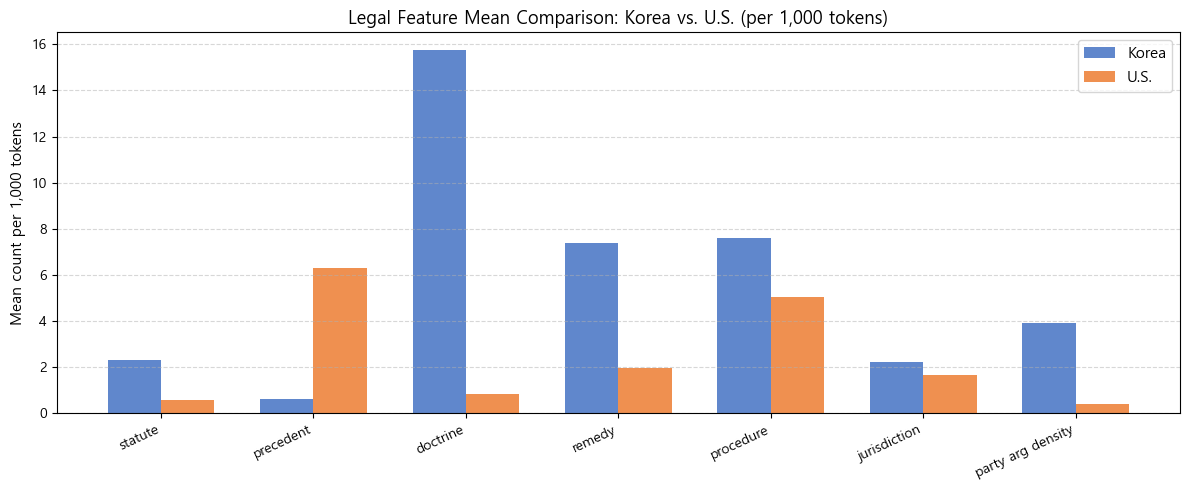

저장: outputs\plots\01_feature_mean_barplot.png


In [8]:
DENSITY_ONLY = [
    "statute_per_1k", "precedent_per_1k",
    "doctrine_per_1k", "remedy_per_1k",
    "procedure_per_1k", "jurisdiction_per_1k",
    "party_arg_density",
]

kr_means = kr_fv[DENSITY_ONLY].mean()
us_means = us_fv[DENSITY_ONLY].mean()

x      = np.arange(len(DENSITY_ONLY))
width  = 0.35
labels = [f.replace("_per_1k", "").replace("_", " ") for f in DENSITY_ONLY]

fig, ax = plt.subplots(figsize=(12, 5))
bars_kr = ax.bar(x - width/2, kr_means.values, width, label="Korea",  color="#4472C4", alpha=0.85)
bars_us = ax.bar(x + width/2, us_means.values, width, label="U.S.",   color="#ED7D31", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=10)
ax.set_ylabel("Mean count per 1,000 tokens", fontsize=11)
ax.set_title("Legal Feature Mean Comparison: Korea vs. U.S. (per 1,000 tokens)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_feature_mean_barplot.png", dpi=150)
plt.show()
print("저장:", PLOT_DIR / "01_feature_mean_barplot.png")

### 7-2. Box plot (분포 및 outlier 확인)

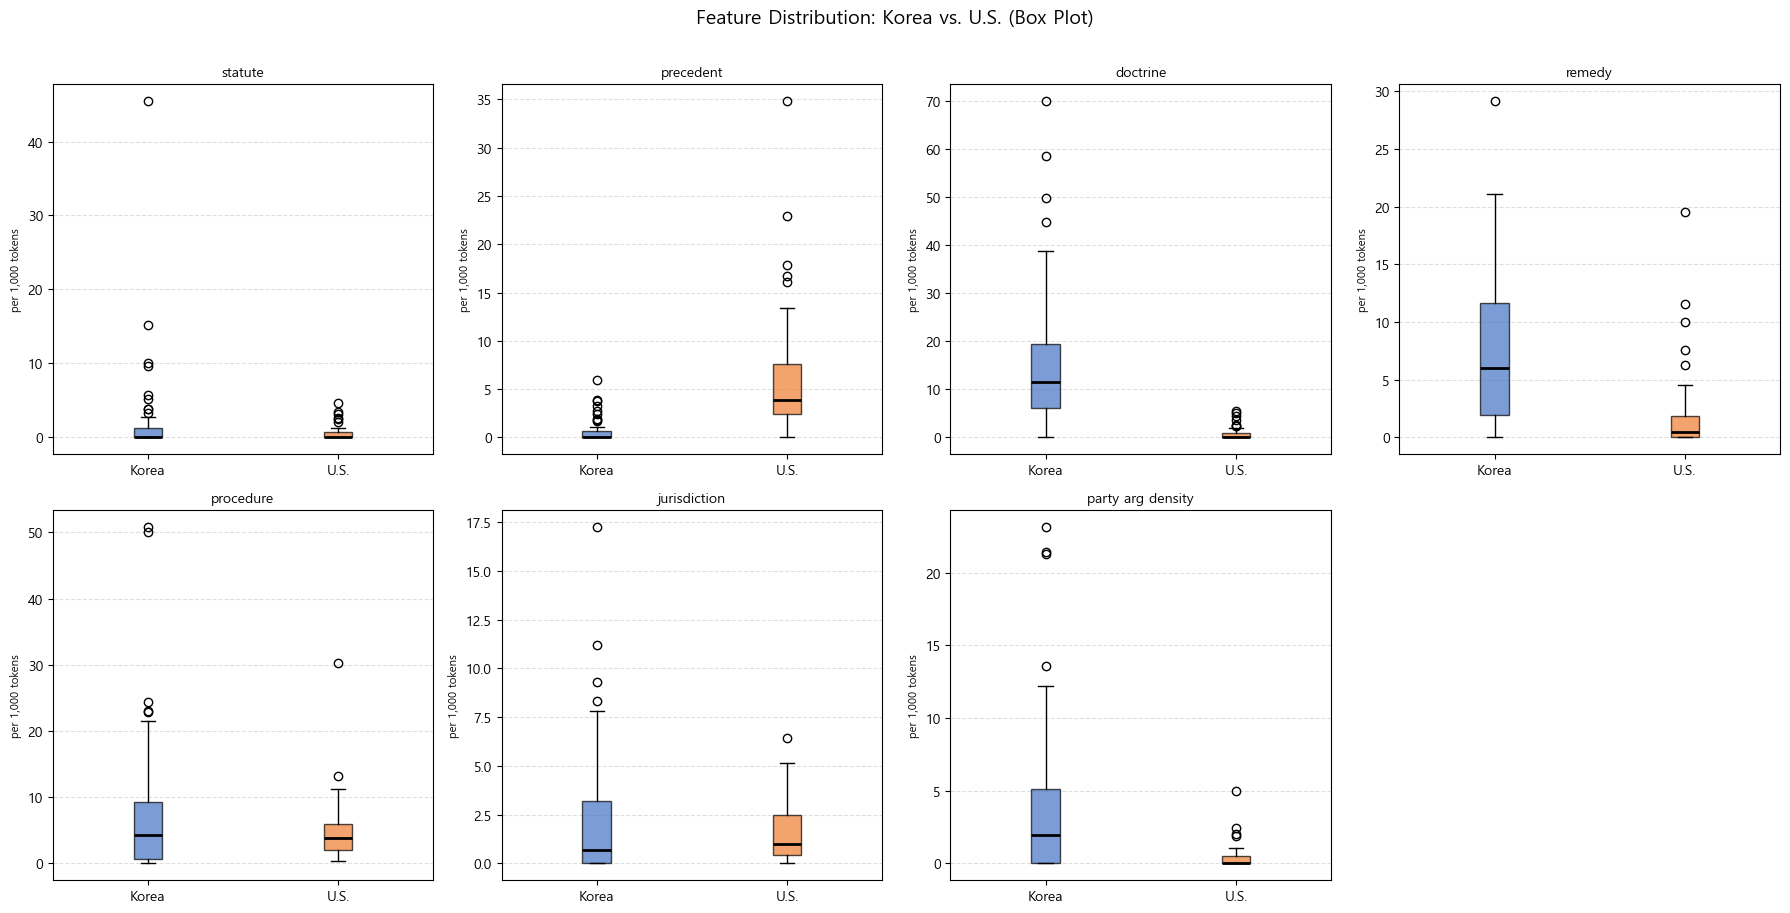

저장: outputs\plots\02_feature_boxplot.png


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(DENSITY_ONLY):
    ax = axes[i]
    kr_vals = kr_fv[feat].replace(-1, np.nan).dropna()
    us_vals = us_fv[feat].replace(-1, np.nan).dropna()

    bp = ax.boxplot(
        [kr_vals, us_vals],
        labels=["Korea", "U.S."],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
    )
    bp["boxes"][0].set_facecolor("#4472C4")
    bp["boxes"][1].set_facecolor("#ED7D31")
    for patch in bp["boxes"]:
        patch.set_alpha(0.7)

    title = feat.replace("_per_1k", "").replace("_", " ")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("per 1,000 tokens", fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# 마지막 빈 subplot 숨기기
for j in range(len(DENSITY_ONLY), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distribution: Korea vs. U.S. (Box Plot)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / "02_feature_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장:", PLOT_DIR / "02_feature_boxplot.png")

### 7-3. Heatmap (판례 100개 × feature matrix)

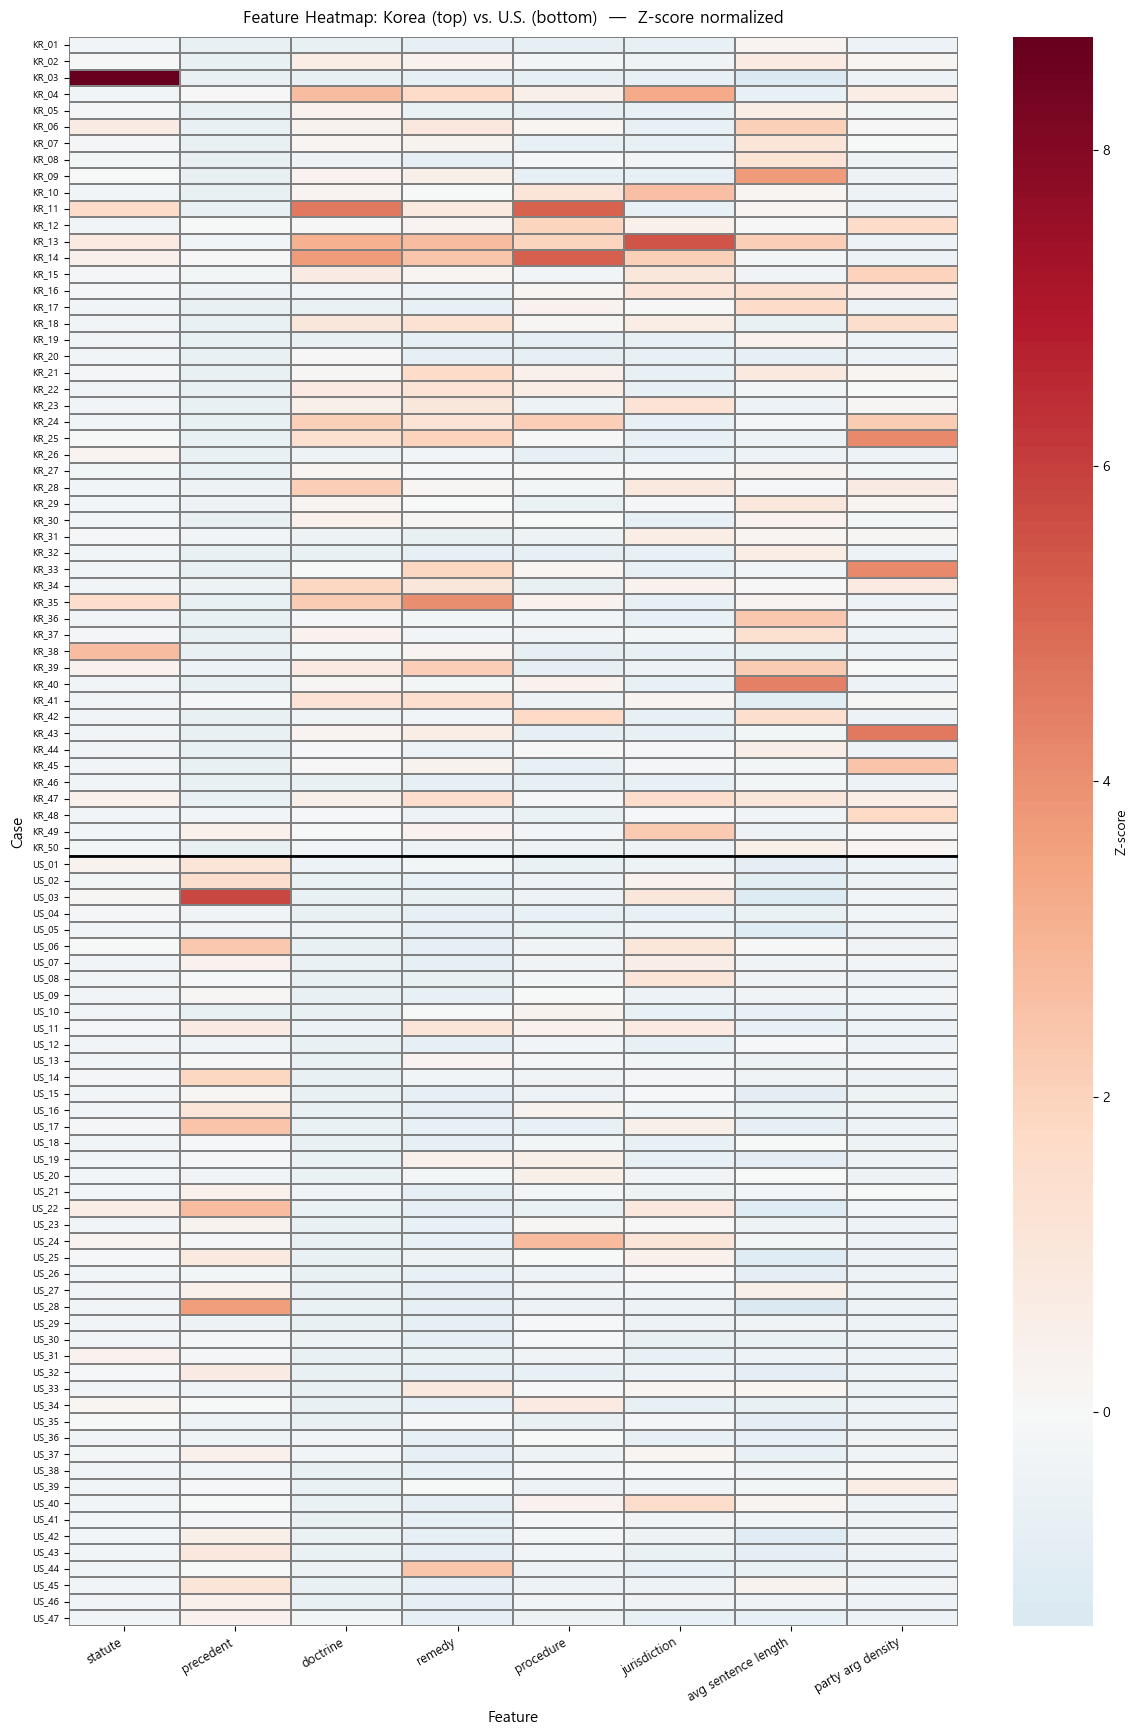

저장: outputs\plots\03_feature_heatmap.png


In [10]:
heat_features = [
    "statute_per_1k", "precedent_per_1k",
    "doctrine_per_1k", "remedy_per_1k",
    "procedure_per_1k", "jurisdiction_per_1k",
    "avg_sentence_length", "party_arg_density",
]

heat_df = fv_df[["case_id", "jurisdiction"] + heat_features].copy()

# Z-score 정규화 (feature 간 scale 차이 제거)
scaler = StandardScaler()
heat_scaled = scaler.fit_transform(heat_df[heat_features].fillna(0))
heat_scaled_df = pd.DataFrame(heat_scaled, columns=heat_features)

# 행 레이블: KR_01 ... KR_50, US_01 ... US_50
row_labels = [
    f"{j}_" + str(i+1).zfill(2)
    for j, grp in [("KR", kr_fv), ("US", us_fv)]
    for i in range(len(grp))
]

fig, ax = plt.subplots(figsize=(12, max(10, len(fv_df) * 0.18)))
sns.heatmap(
    heat_scaled_df,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    xticklabels=[f.replace("_per_1k","").replace("_"," ") for f in heat_features],
    yticklabels=row_labels,
    linewidths=0.2,
    linecolor="grey",
    cbar_kws={"label": "Z-score"},
)

# KR/US 경계선
ax.axhline(len(kr_fv), color="black", linewidth=2)

ax.set_title("Feature Heatmap: Korea (top) vs. U.S. (bottom)  —  Z-score normalized",
             fontsize=12, pad=10)
ax.set_xlabel("Feature", fontsize=11)
ax.set_ylabel("Case", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_feature_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장:", PLOT_DIR / "03_feature_heatmap.png")

### 7-4. PCA (2D 분리 시각화)

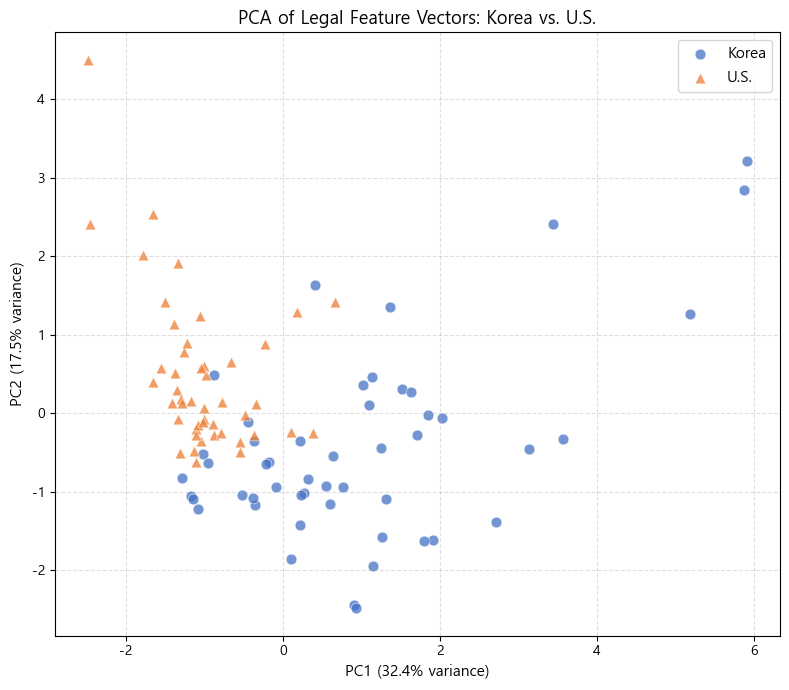

PCA 설명 분산: PC1=32.4%, PC2=17.5%
저장: outputs\plots\04_pca.png


In [11]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(heat_scaled_df.fillna(0))
var_ratio = pca.explained_variance_ratio_

kr_idx = range(len(kr_fv))
us_idx = range(len(kr_fv), len(fv_df))

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(
    pca_coords[list(kr_idx), 0], pca_coords[list(kr_idx), 1],
    c="#4472C4", label="Korea", alpha=0.75, s=60, edgecolors="white", linewidths=0.5
)
ax.scatter(
    pca_coords[list(us_idx), 0], pca_coords[list(us_idx), 1],
    c="#ED7D31", label="U.S.",  alpha=0.75, s=60, edgecolors="white", linewidths=0.5,
    marker="^"
)
ax.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}% variance)", fontsize=11)
ax.set_title("PCA of Legal Feature Vectors: Korea vs. U.S.", fontsize=13)
ax.legend(fontsize=11)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_pca.png", dpi=150)
plt.show()
print(f"PCA 설명 분산: PC1={var_ratio[0]*100:.1f}%, PC2={var_ratio[1]*100:.1f}%")
print("저장:", PLOT_DIR / "04_pca.png")

### 7-5. PCA Loading plot (PC1에 가장 기여하는 feature 확인)

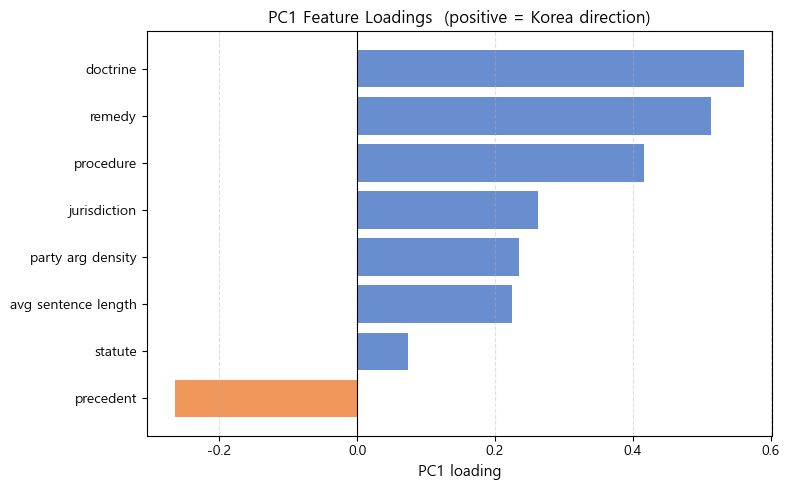

                          PC1       PC2
precedent           -0.263814  0.611874
statute              0.073292  0.090626
avg sentence length  0.224509 -0.441500
party arg density    0.234216 -0.229394
jurisdiction         0.262508  0.536201
procedure            0.415937  0.260932
remedy               0.513172 -0.015674
doctrine             0.560811  0.118369


In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=[f.replace("_per_1k","").replace("_"," ") for f in heat_features],
    columns=["PC1", "PC2"]
).sort_values("PC1")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4472C4" if v >= 0 else "#ED7D31" for v in loadings["PC1"]]
ax.barh(loadings.index, loadings["PC1"], color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("PC1 loading", fontsize=11)
ax.set_title("PC1 Feature Loadings  (positive = Korea direction)", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_pca_loadings.png", dpi=150)
plt.show()
print(loadings.to_string())

## 8. 최종 요약

In [13]:
print("=" * 60)
print("PILOT CORPUS ANALYSIS  —  SUMMARY")
print("=" * 60)
print(f"\n  KR 판례 수 : {len(kr_fv)}")
print(f"  US 판례 수 : {len(us_fv)}")

print("\n[통계적으로 유의하거나 effect size가 medium 이상인 feature]")
notable = test_df[
    (test_df["sig (α=0.05)"] == "*") |
    (test_df["effect size"].isin(["medium", "large"]))
]
if len(notable):
    print(notable[["feature", "p (Bonf.)", "Cliff's δ", "effect size"]].to_string(index=False))
else:
    print("  (해당 없음 — feature 확장 또는 표본 수 증가 권장)")

print("\n[저장된 파일]")
for p in sorted(PLOT_DIR.glob("*.png")):
    print(f"  {p}")
print(f"  {FV_OUTPUT}")

PILOT CORPUS ANALYSIS  —  SUMMARY

  KR 판례 수 : 50
  US 판례 수 : 47

[통계적으로 유의하거나 effect size가 medium 이상인 feature]
             feature  p (Bonf.)  Cliff's δ effect size
doc_length_sentences     0.0000    -0.8826       large
    precedent_per_1k     0.0000    -0.8464       large
     doctrine_per_1k     0.0000     0.8149       large
   doc_length_tokens     0.0000    -0.8026       large
 avg_sentence_length     0.0000     0.6472       large
    citation_density     0.0000    -0.5979       large
       remedy_per_1k     0.0000     0.5647       large
   party_arg_density     0.0009     0.4306      medium

[저장된 파일]
  outputs\plots\01_feature_mean_barplot.png
  outputs\plots\02_feature_boxplot.png
  outputs\plots\03_feature_heatmap.png
  outputs\plots\04_pca.png
  outputs\plots\05_pca_loadings.png
  outputs\feature_vectors.csv
